#  Telecom Customer Churn Prediction — Exploratory Data Analysis (EDA)

### Phase 2 : Exploratory Data Analysis

#### Importing Libraries

In [1]:
%cd "C:\Users\Lenovo\Desktop\github projects\telcos customer churn"

C:\Users\Lenovo\Desktop\github projects\telcos customer churn


In [2]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt
import  seaborn as sns

from scipy import stats


from src.data_ingestion import DataIngestion

pd.set_option("display.max_columns",None)
sns.set_style("whitegrid")


#### Load Dataset 

In [3]:
ingestion=DataIngestion()
df=ingestion.load_data()
print(df.shape)

(7043, 21)


#### Clean Dataset fro EDA

In [4]:
## lets fix the data typesof total charges 

df["TotalCharges"]=df["TotalCharges"].replace(" ",np.nan)

df["TotalCharges"]=df["TotalCharges"].astype(float)

print(df["TotalCharges"].dtype)

float64


#### Check Missing values

In [5]:
missing_df=DataIngestion.dataset_summary(df)
missing_df[missing_df["Missing Values"]>0]

,Data Types,Missing Values,Missing Percentage,Unique Values
TotalCharges,float64,11,0.16,6530


#  Statistical Exploratory Data Analysis

#### Describe

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.000,0.0000,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


In [7]:
df.describe(include="object").T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


#### Skewness

In [8]:
numerical_features=["tenure","MonthlyCharges", "TotalCharges"]

skew_df=pd.DataFrame({"Skewness":df[numerical_features].skew()})
skew_df

,Skewness
tenure,0.239540
MonthlyCharges,-0.220524
TotalCharges,0.961642


####  Kurtosis

In [9]:
kurtosis_df=pd.DataFrame({"Kurtosis":df[numerical_features].kurtosis()})
kurtosis_df

,Kurtosis
tenure,-1.387372
MonthlyCharges,-1.257260
TotalCharges,-0.231799


#### Missing Value Summary

In [10]:
missing_df

,Data Types,Missing Values,Missing Percentage,Unique Values
customerID,object,0,0.00,7043
gender,object,0,0.00,2
SeniorCitizen,int64,0,0.00,2
Partner,object,0,0.00,2
Dependents,object,0,0.00,2
tenure,int64,0,0.00,73
PhoneService,object,0,0.00,2
MultipleLines,object,0,0.00,3
InternetService,object,0,0.00,3
OnlineSecurity,object,0,0.00,3


#### Duplicate Summary

In [11]:
print(f"Duplicate Rows :{df.duplicated().sum()}")

Duplicate Rows :0


In [14]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(8,5)
plt.rcParams["axes.titlesize"]=16
plt.rcParams["axes.titleweight"]="bold"
plt.rcParams["axes.labelsize"]=12
plt.rcParams["xtick.labelsize"]=10
plt.rcParams["ytick.labelsize"]=10


# Univariate Analysis

## Visualization 1 — Customer Churn Distribution

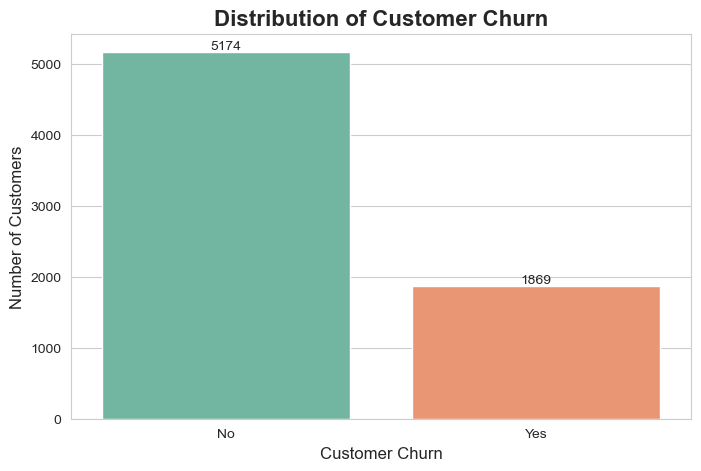

In [23]:
ax=sns.countplot(data=df,x="Churn",hue="Churn",palette="Set2",legend=False)

for container in ax.containers:
    ax.bar_label(container)


plt.title("Distribution of Customer Churn")
plt.xlabel("Customer Churn")
plt.ylabel("Number of Customers")

plt.show()


## Visualization 2 — Gender Distribution

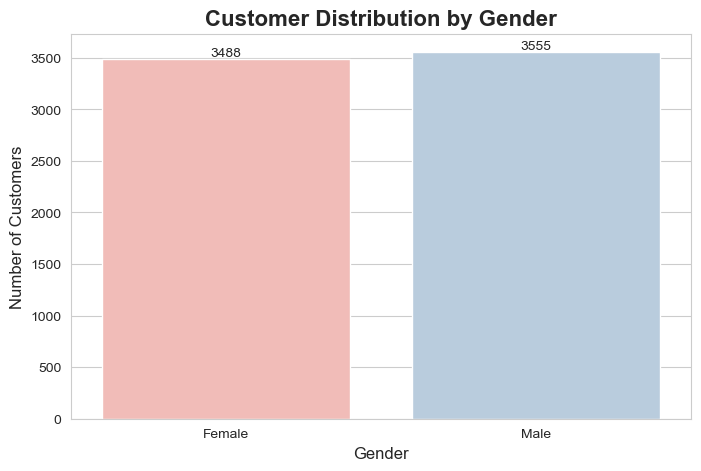

In [24]:
ax=sns.countplot(data=df,x="gender",hue="gender",palette="Pastel1",legend=False)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

- Male and Female customers are almost equally distributed.
- Gender alone may not be a strong predictor of churn.

## Visualization 3 — Senior Citizen Distribution

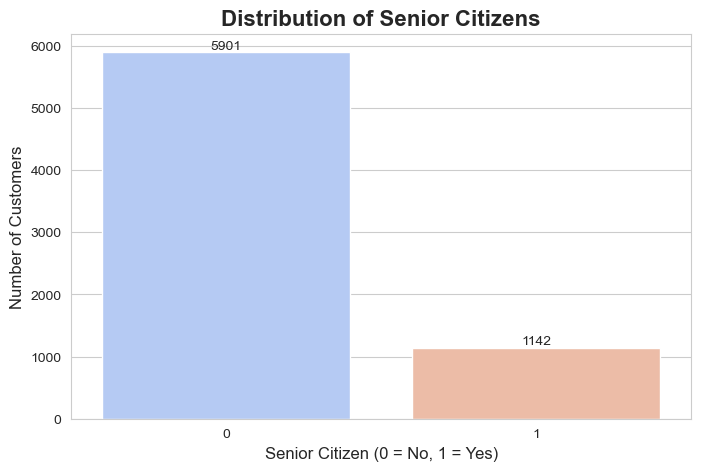

In [25]:
ax=sns.countplot(data=df,x="SeniorCitizen",hue="SeniorCitizen",palette="coolwarm",legend=False)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Senior Citizens")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

- Senior citizens form a much smaller customer segment.
- We'll investigate whether this smaller group has a higher churn rate in the next section.

## Visualization 4 — Customers with Partners

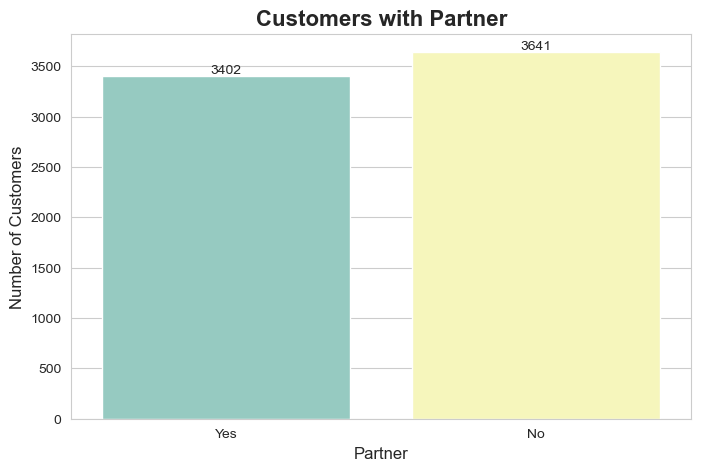

In [26]:
ax=sns.countplot(data=df,x="Partner",hue="Partner", palette="Set3",legend=False)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customers with Partner")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")

plt.show()

- Customers are fairly evenly divided between having a partner and not having a partner.

## Visualization 5 — Customers with Dependents

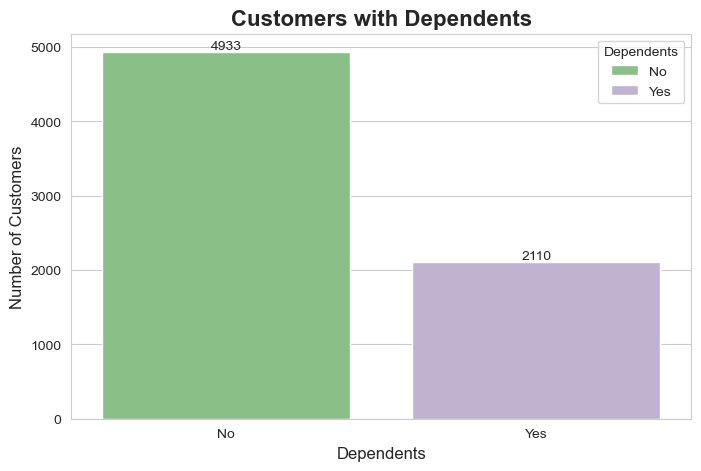

In [27]:
ax=sns.countplot(data=df,x="Dependents",hue="Dependents",palette="Accent",legend=True)


for container in ax.containers:
    ax.bar_label(container)

plt.title("Customers with Dependents")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")

plt.show()

- Most customers do not have dependents.

## Visualization 6 — Customer Tenure Distribution

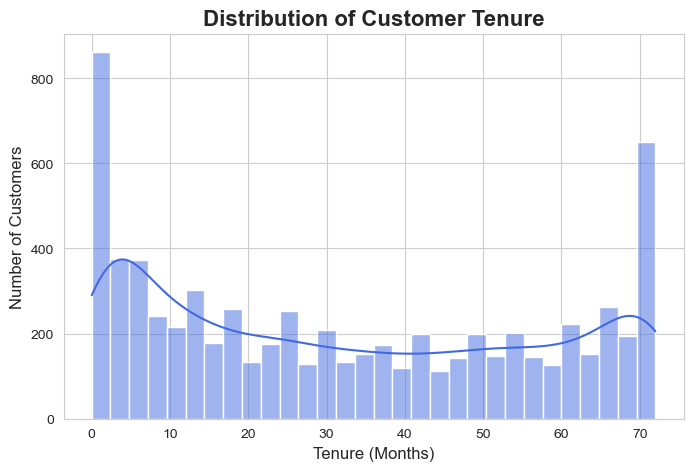

In [28]:
ax=sns.histplot(data=df, x="tenure",bins=30,kde=True,color="royalblue")
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

- A large number of customers have very low tenure.
- Another concentration exists among long-term customers.

## Visualization 7 — Monthly Charges Distribution

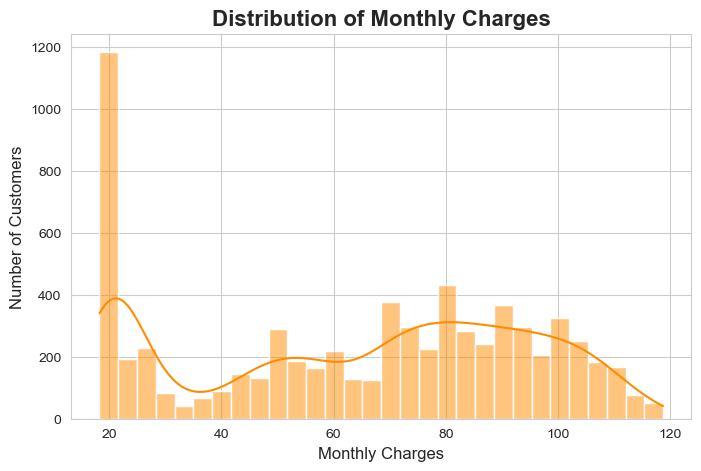

In [29]:
ax=sns.histplot(data=df,x="MonthlyCharges",bins=30,kde=True, color="darkorange")

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

- Monthly charges are not normally distributed.

## Visualization 8 — Total Charges Distribution

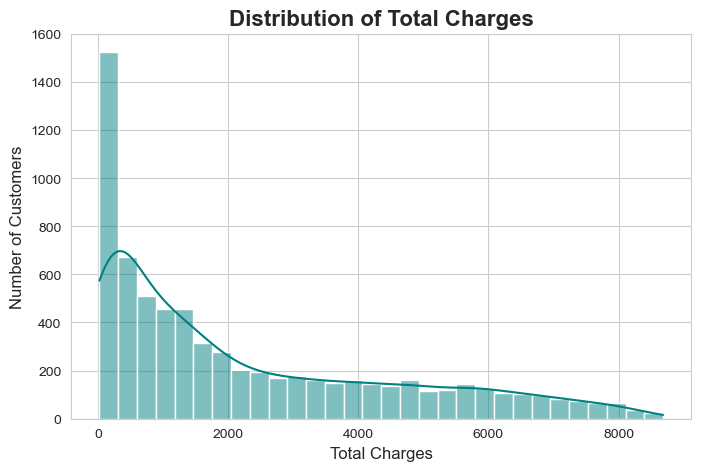

In [30]:
sns.histplot(data=df,x="TotalCharges",bins=30,kde=True,color="teal")

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.show()


- Total charges are positively skewed.

## Visualization 9 — Contract Type Distribution

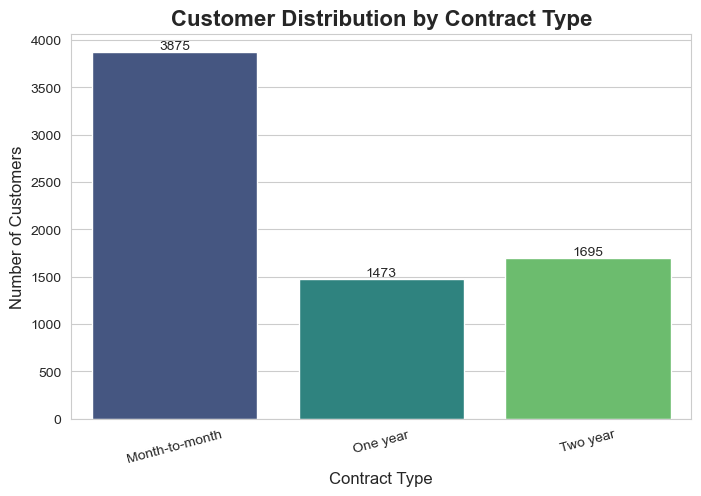

In [33]:
ax=sns.countplot(data=df,x="Contract",hue="Contract",palette="viridis",legend=False)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

- Month-to-Month contracts dominate the customer base.

## Visualization 10 — Internet Service Distribution

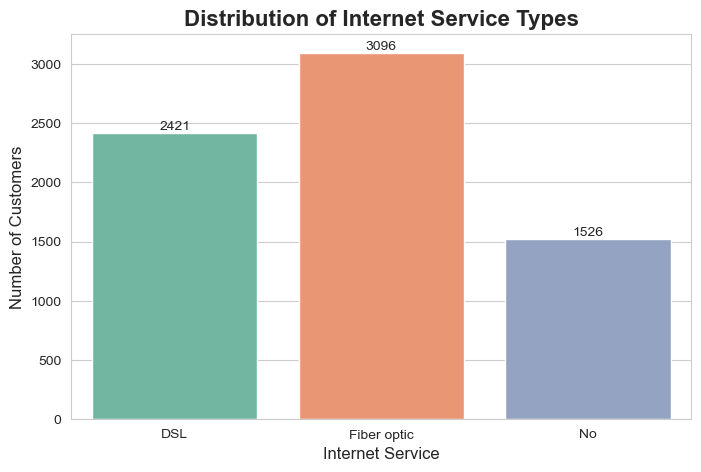

In [35]:
ax = sns.countplot(data=df,x="InternetService",hue="InternetService",palette="Set2",legend=False)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Internet Service Types")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

- Fiber Optic and DSL customers represent major internet segments.
- Customers without internet service form the smallest group.

#  Univariate Analysis Summary

In [39]:

pd.set_option("display.max_colwidth", None)
univariate_summary=pd.DataFrame({"Feature":["Churn","Gender","SeniorCitizen","Partner","Dependents","Tenure","MonthlyCharges", "TotalCharges","Contract","InternetService"],
                                 "Key Observation":["Dataset is moderately imbalanced (73% vs 27%).",
                                                    "Male and Female customers are almost equally distributed.",
        "Senior citizens are a smaller customer segment.","Partner distribution is fairly balanced.",
        "Most customers do not have dependents.","Tenure shows many new and many loyal customers.",
        "Monthly charges have multiple billing clusters.","Total charges are positively skewed.",
        "Month-to-Month contracts dominate.","Fiber Optic and DSL are the major internet services."]})

univariate_summary

,Feature,Key Observation
0,Churn,Dataset is moderately imbalanced (73% vs 27%).
1,Gender,Male and Female customers are almost equally distributed.
2,SeniorCitizen,Senior citizens are a smaller customer segment.
3,Partner,Partner distribution is fairly balanced.
4,Dependents,Most customers do not have dependents.
5,Tenure,Tenure shows many new and many loyal customers.
6,MonthlyCharges,Monthly charges have multiple billing clusters.
7,TotalCharges,Total charges are positively skewed.
8,Contract,Month-to-Month contracts dominate.
9,InternetService,Fiber Optic and DSL are the major internet services.
